***This is only Exploratory Data Analysis.*** ***Refer to FD Forecasting-ModelB for Model building and final prediction***

In [1]:
#importing all required packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# **Preprocessing**

In [2]:
#train file
df= pd.read_csv("C:/Users/3939/Documents/MMA Courses/MMA 869/Hackathon/mergedtrain.csv")
df.head()

,id,week,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
0,1379560,1,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1,1018704,2,55,1885,135.83,152.29,0,0,323,Beverages,Thai,647,56,TYPE_C,2.0
2,1196273,3,55,1885,132.92,133.92,0,0,96,Beverages,Thai,647,56,TYPE_C,2.0
3,1116527,4,55,1885,135.86,134.86,0,0,163,Beverages,Thai,647,56,TYPE_C,2.0
4,1343872,5,55,1885,146.50,147.50,0,0,215,Beverages,Thai,647,56,TYPE_C,2.0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 456548 entries, 0 to 456547
Data columns (total 15 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   week                   456548 non-null  int64  
 2   center_id              456548 non-null  int64  
 3   meal_id                456548 non-null  int64  
 4   checkout_price         456548 non-null  float64
 5   base_price             456548 non-null  float64
 6   emailer_for_promotion  456548 non-null  int64  
 7   homepage_featured      456548 non-null  int64  
 8   num_orders             456548 non-null  int64  
 9   category               456548 non-null  object 
 10  cuisine                456548 non-null  object 
 11  city_code              456548 non-null  int64  
 12  region_code            456548 non-null  int64  
 13  center_type            456548 non-null  object 
 14  op_area                456548 non-nu

In [4]:
df.nunique()

id                       456548
week                        145
center_id                    77
meal_id                      51
checkout_price             1992
base_price                 1907
emailer_for_promotion         2
homepage_featured             2
num_orders                 1250
category                     14
cuisine                       4
city_code                    51
region_code                   8
center_type                   3
op_area                      30
dtype: int64

In [5]:
df['id'].duplicated().sum()

0

**Exploratory Data Analysis**

In [6]:
# Select only the numerical columns before calculating correlations.
numerical_df = df.select_dtypes(include=['number'])

# Our output (target) variable is num_orders
If we see correlation with it, main features which has high correlation are:

Checkout_price
base_price
Emailer_promotion
Homepage_freatured
Op_area
Let’s see all features comparison.

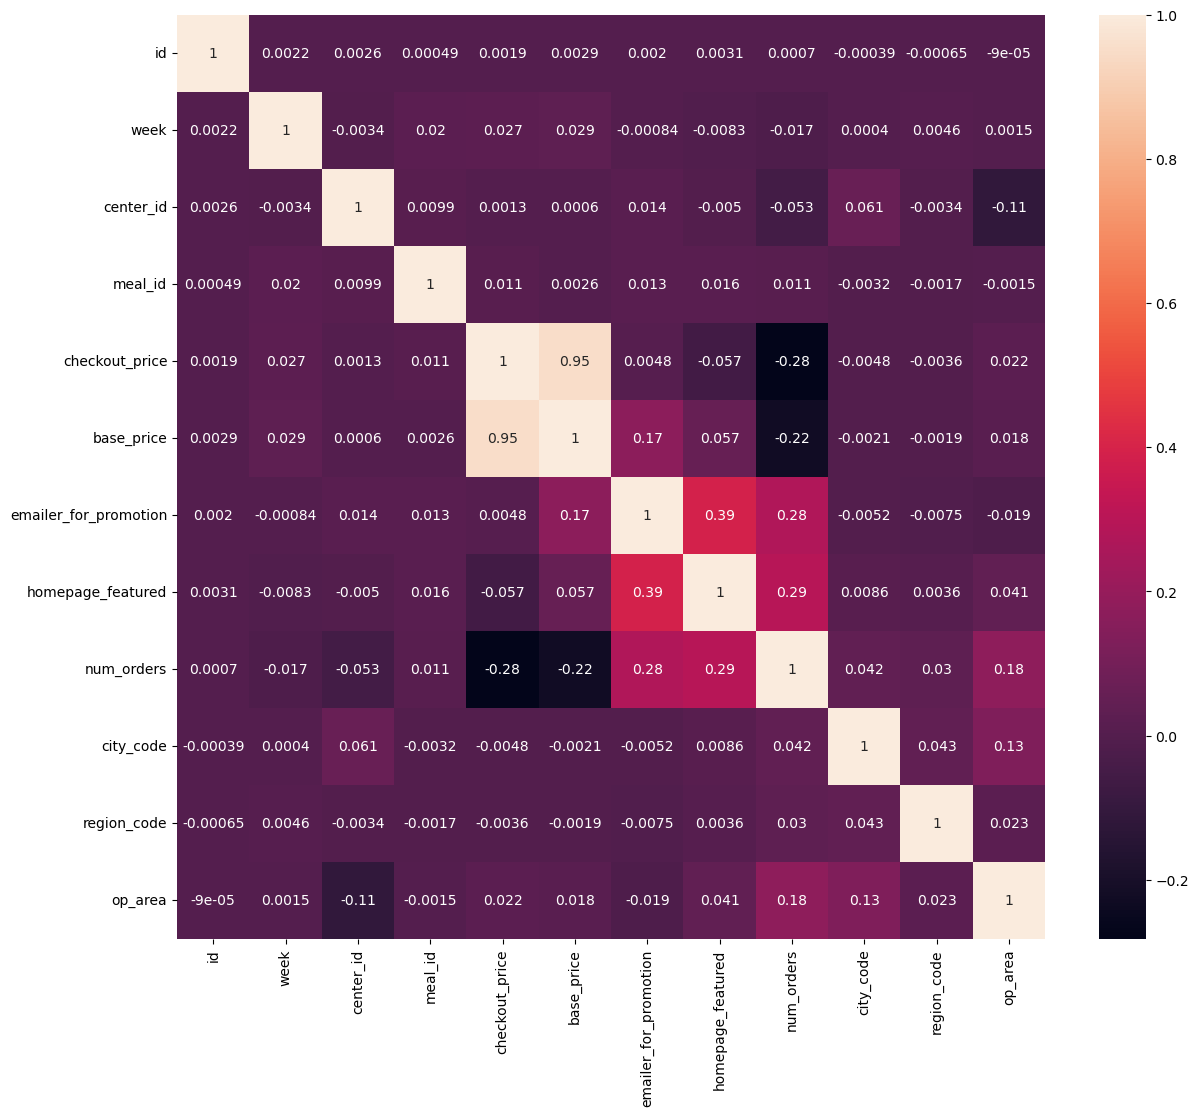

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select only the numerical columns before calculating correlations.
numerical_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(14,12))
sns.heatmap(numerical_df.corr(),annot=True)
plt.show()

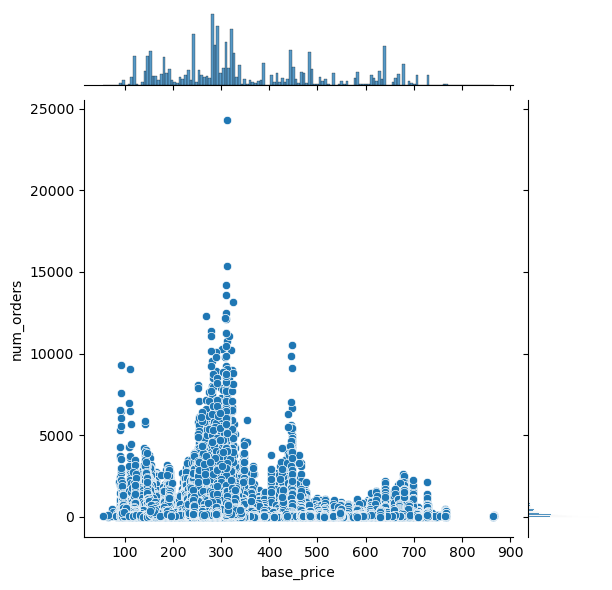

In [8]:
sns.jointplot(x='base_price',y='num_orders',data=df)

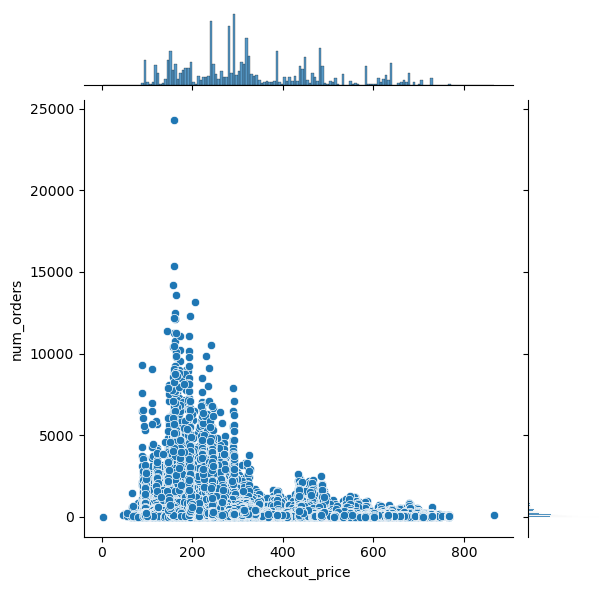

In [9]:
sns.jointplot(x='checkout_price',y='num_orders',data=df)

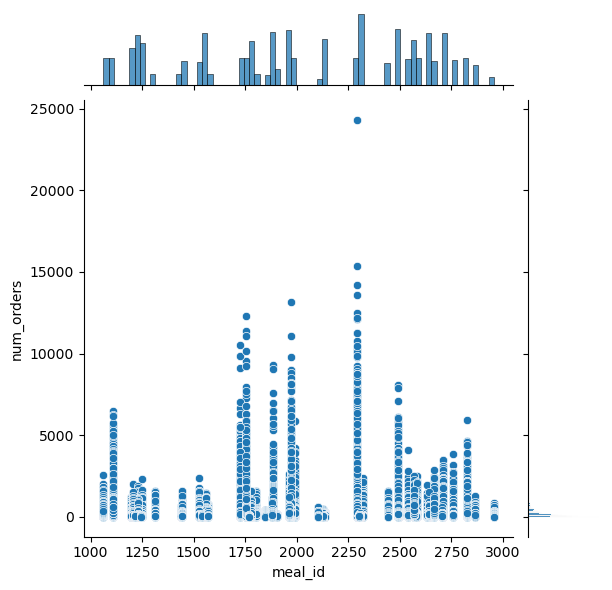

In [10]:
sns.jointplot(x='meal_id',y='num_orders',data=df)

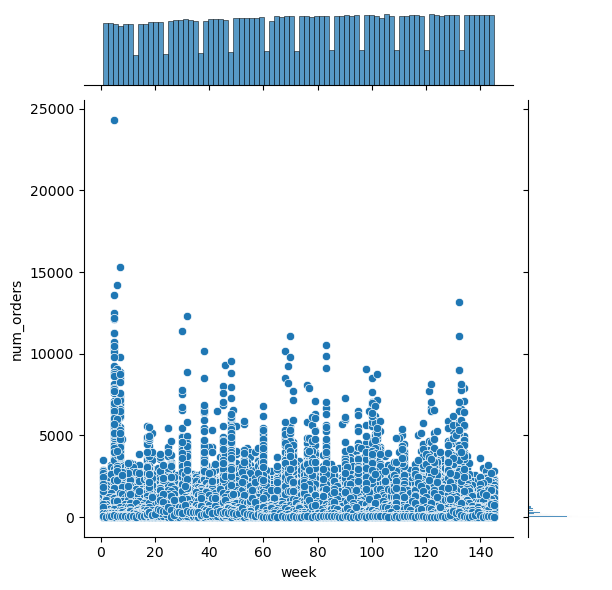

In [11]:
sns.jointplot(x='week',y='num_orders',data=df)

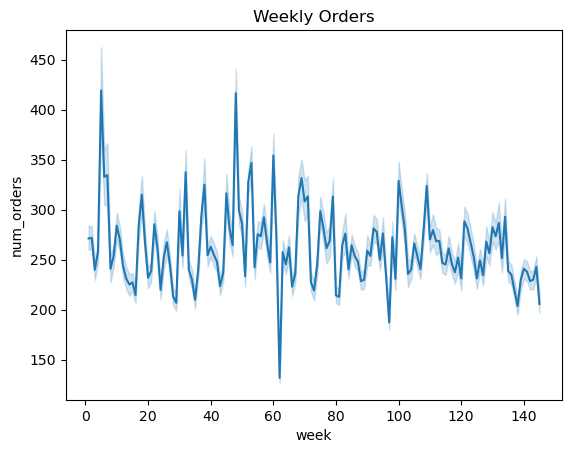

In [12]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Assuming df is your DataFrame and it contains 'week' and 'num_orders' columns
sns.lineplot(x='week', y='num_orders', data=df)
plt.title('Weekly Orders')
plt.show()

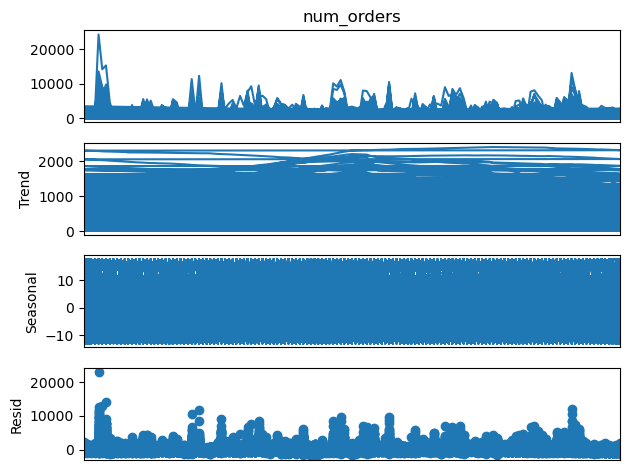

In [13]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Assuming 'week' is a datetime-like index or can be converted to a datetime index
df['week'] = pd.to_datetime(df['week'])
df.set_index('week', inplace=True)

# Decompose the time series
result = seasonal_decompose(df['num_orders'], model='additive', period=145)  # Adjust period based on your data

# Plot the decomposed components
result.plot()
plt.show()

In [14]:
from scipy.signal import find_peaks

# Extracting the seasonal component
seasonal = result.seasonal

# Finding peaks (local maxima)
peaks, _ = find_peaks(seasonal)

# Finding troughs (local minima)
troughs, _ = find_peaks(-seasonal)

# Extracting the exact weeks of peaks and troughs
peak_weeks = seasonal.index[peaks]
trough_weeks = seasonal.index[troughs]

print("Peak Weeks:", peak_weeks)
print("Trough Weeks:", trough_weeks)


Peak Weeks: DatetimeIndex(['1970-01-01 00:00:00.000000004',
               '1970-01-01 00:00:00.000000007',
               '1970-01-01 00:00:00.000000009',
               '1970-01-01 00:00:00.000000011',
               '1970-01-01 00:00:00.000000016',
               '1970-01-01 00:00:00.000000021',
               '1970-01-01 00:00:00.000000025',
               '1970-01-01 00:00:00.000000031',
               '1970-01-01 00:00:00.000000034',
               '1970-01-01 00:00:00.000000038',
               ...
               '1970-01-01 00:00:00.000000105',
               '1970-01-01 00:00:00.000000111',
               '1970-01-01 00:00:00.000000117',
               '1970-01-01 00:00:00.000000122',
               '1970-01-01 00:00:00.000000125',
               '1970-01-01 00:00:00.000000128',
               '1970-01-01 00:00:00.000000130',
               '1970-01-01 00:00:00.000000134',
               '1970-01-01 00:00:00.000000137',
               '1970-01-01 00:00:00.000000143'],
        

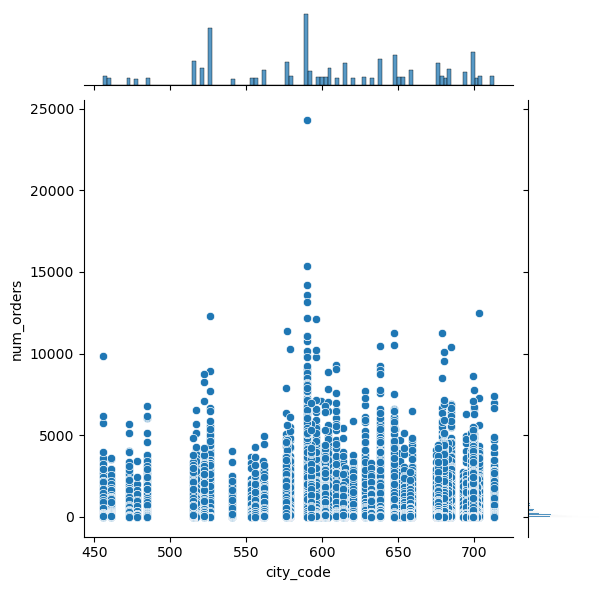

In [15]:
sns.jointplot(x='city_code',y='num_orders',data=df)

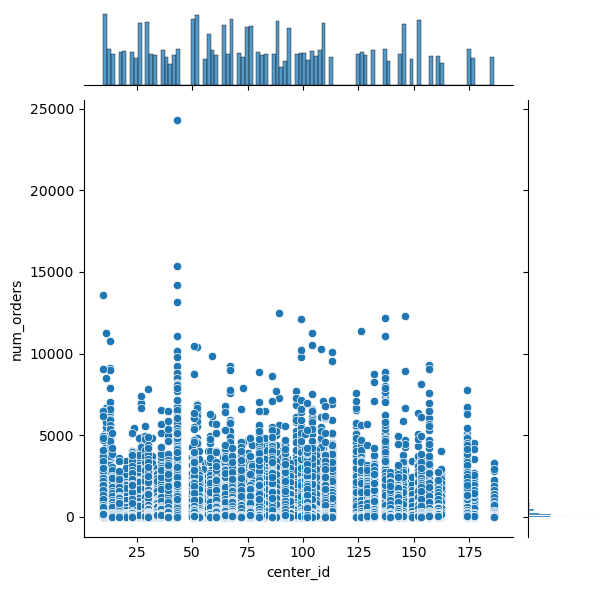

In [16]:
sns.jointplot(x='center_id',y='num_orders',data=df)

<Axes: xlabel='emailer_for_promotion', ylabel='num_orders'>

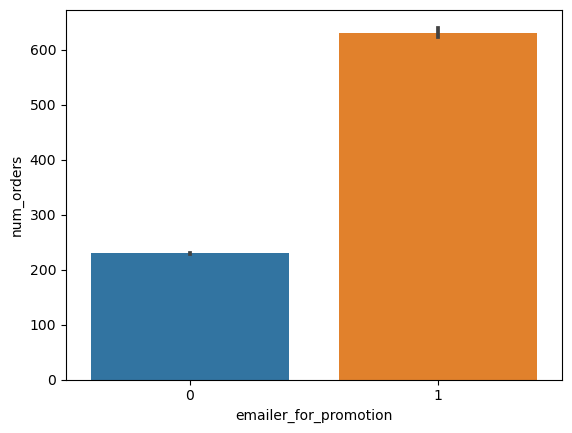

In [17]:
#relation between num_orders and emailer_for_promotion....
#this shows if the mail has sent there are more no of orders
sns.barplot(x = 'emailer_for_promotion',y = 'num_orders',data =df)

<Axes: xlabel='homepage_featured', ylabel='num_orders'>

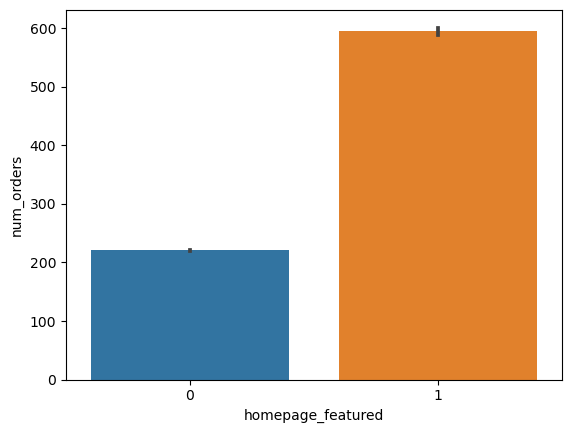

In [18]:
sns.barplot(x = 'homepage_featured',y = 'num_orders',data =df)

<Axes: xlabel='category', ylabel='num_orders'>

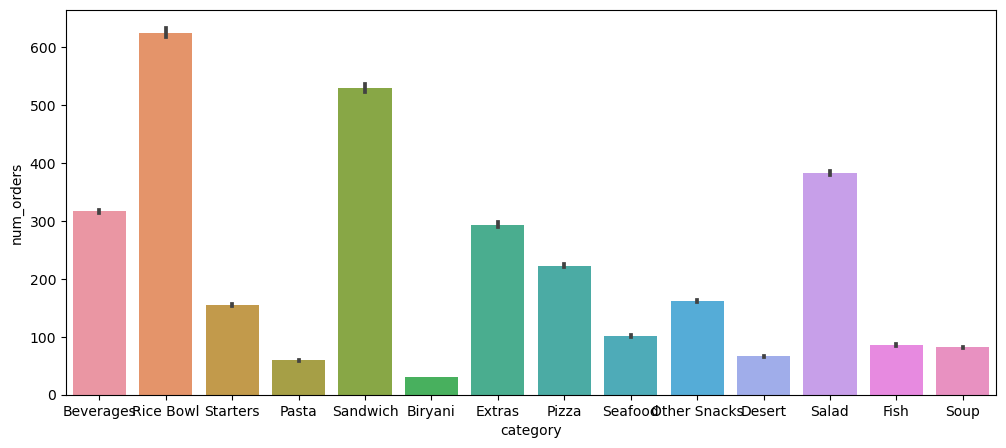

In [19]:
plt.figure(figsize=(12,5))
sns.barplot(x = 'category',y = 'num_orders',data =df)

<Axes: xlabel='cuisine', ylabel='num_orders'>

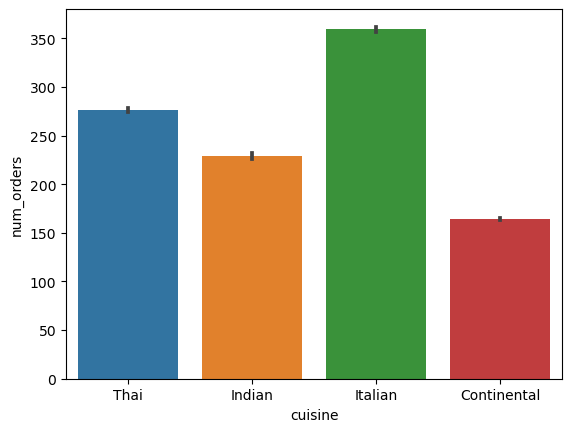

In [20]:
sns.barplot(x = 'cuisine',y = 'num_orders',data =df)

<Axes: xlabel='region_code', ylabel='num_orders'>

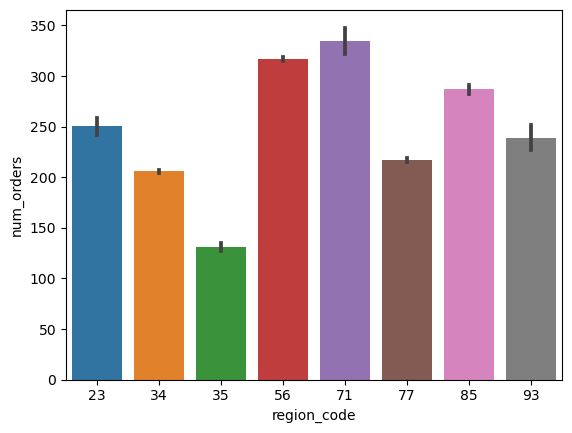

In [21]:
sns.barplot(x = 'region_code',y = 'num_orders',data =df)

<Axes: xlabel='center_type', ylabel='num_orders'>

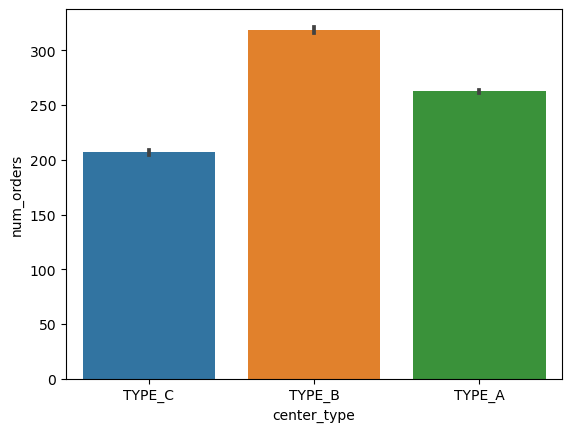

In [22]:
sns.barplot(x = 'center_type',y = 'num_orders',data =df)

<Axes: xlabel='op_area', ylabel='num_orders'>

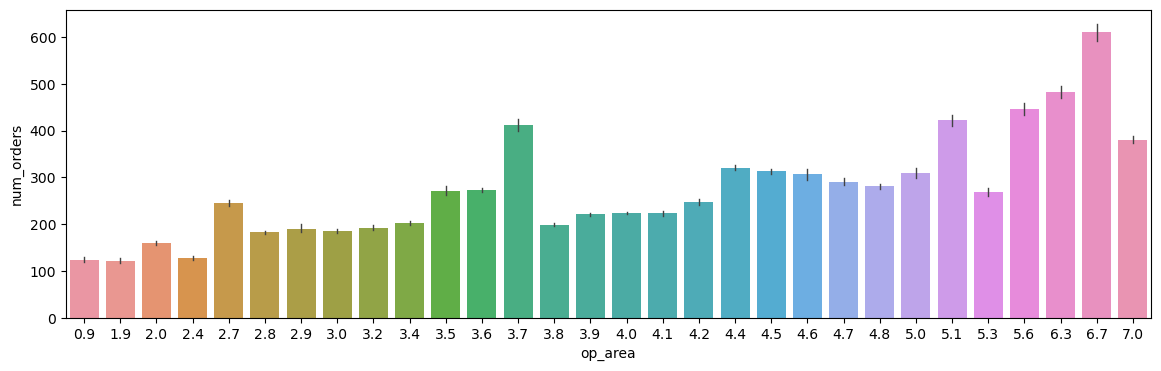

In [23]:
plt.figure(figsize=(14,4))
sns.barplot(x = 'op_area',y = 'num_orders',data =df,errwidth = 1)

**feature engineering**

In [24]:
df.head()

,id,center_id,meal_id,checkout_price,base_price,emailer_for_promotion,homepage_featured,num_orders,category,cuisine,city_code,region_code,center_type,op_area
week,,,,,,,,,,,,,,
1970-01-01 00:00:00.000000001,1379560,55,1885,136.83,152.29,0,0,177,Beverages,Thai,647,56,TYPE_C,2.0
1970-01-01 00:00:00.000000002,1018704,55,1885,135.83,152.29,0,0,323,Beverages,Thai,647,56,TYPE_C,2.0
1970-01-01 00:00:00.000000003,1196273,55,1885,132.92,133.92,0,0,96,Beverages,Thai,647,56,TYPE_C,2.0
1970-01-01 00:00:00.000000004,1116527,55,1885,135.86,134.86,0,0,163,Beverages,Thai,647,56,TYPE_C,2.0
1970-01-01 00:00:00.000000005,1343872,55,1885,146.50,147.50,0,0,215,Beverages,Thai,647,56,TYPE_C,2.0


In [25]:
train_df=df.copy()

In [26]:
#Seperating the target feature

X_train = train_df.drop(columns=['num_orders'])
y_train = train_df['num_orders']

In [27]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 456548 entries, 1970-01-01 00:00:00.000000001 to 1970-01-01 00:00:00.000000145
Data columns (total 13 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   id                     456548 non-null  int64  
 1   center_id              456548 non-null  int64  
 2   meal_id                456548 non-null  int64  
 3   checkout_price         456548 non-null  float64
 4   base_price             456548 non-null  float64
 5   emailer_for_promotion  456548 non-null  int64  
 6   homepage_featured      456548 non-null  int64  
 7   category               456548 non-null  object 
 8   cuisine                456548 non-null  object 
 9   city_code              456548 non-null  int64  
 10  region_code            456548 non-null  int64  
 11  center_type            456548 non-null  object 
 12  op_area                456548 non-null  float64
dtypes: float64(3), int64(7), object(3)


In [28]:
print(X_train.columns)

Index(['id', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'category', 'cuisine',
       'city_code', 'region_code', 'center_type', 'op_area'],
      dtype='object')


In [29]:
# Verify train_df columns
print("Columns in train_df:", train_df.columns)

# Verify X_train columns
print("Columns in X_train:", X_train.columns)

# Ensure 'meal_id' is present and aligns
if 'meal_id' in train_df.columns:
    print("meal_id exists in train_df")

if 'meal_id' in X_train.columns:
    print("meal_id exists in X_train")
else:
    print("meal_id missing in X_train")


Columns in train_df: Index(['id', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'num_orders', 'category',
       'cuisine', 'city_code', 'region_code', 'center_type', 'op_area'],
      dtype='object')
Columns in X_train: Index(['id', 'center_id', 'meal_id', 'checkout_price', 'base_price',
       'emailer_for_promotion', 'homepage_featured', 'category', 'cuisine',
       'city_code', 'region_code', 'center_type', 'op_area'],
      dtype='object')
meal_id exists in train_df
meal_id exists in X_train


In [30]:
print(train_df.index)
print(X_train.index)

DatetimeIndex(['1970-01-01 00:00:00.000000001',
               '1970-01-01 00:00:00.000000002',
               '1970-01-01 00:00:00.000000003',
               '1970-01-01 00:00:00.000000004',
               '1970-01-01 00:00:00.000000005',
               '1970-01-01 00:00:00.000000006',
               '1970-01-01 00:00:00.000000007',
               '1970-01-01 00:00:00.000000008',
               '1970-01-01 00:00:00.000000009',
               '1970-01-01 00:00:00.000000010',
               ...
               '1970-01-01 00:00:00.000000136',
               '1970-01-01 00:00:00.000000137',
               '1970-01-01 00:00:00.000000138',
               '1970-01-01 00:00:00.000000139',
               '1970-01-01 00:00:00.000000140',
               '1970-01-01 00:00:00.000000141',
               '1970-01-01 00:00:00.000000142',
               '1970-01-01 00:00:00.000000143',
               '1970-01-01 00:00:00.000000144',
               '1970-01-01 00:00:00.000000145'],
              dtype=

In [ ]:
"""

# Create rolling mean features for num_orders

# Sample data (assuming train_df and X_train are already defined)
# Ensure 'meal_id' is present in both DataFrames
if 'meal_id' in train_df.columns and 'meal_id' in X_train.columns:
    # Compute rolling means for num_orders
    rolling_mean_3 = train_df.groupby('meal_id')['num_orders'].rolling(3).mean().reset_index(level=0, drop=True).fillna(0)
    rolling_mean_7 = train_df.groupby('meal_id')['num_orders'].rolling(7).mean().reset_index(level=0, drop=True).fillna(0)
    
    # Add rolling mean features to X_train
    X_train['num_orders_rolling_mean_3'] = rolling_mean_3
    X_train['num_orders_rolling_mean_7'] = rolling_mean_7
    
    # Fill any remaining NaN values
    X_train['num_orders_rolling_mean_3'].fillna(0, inplace=True)
    X_train['num_orders_rolling_mean_7'].fillna(0, inplace=True)
else:
    print("Error: 'meal_id' column is not present in one of the DataFrames")

"""

In [ ]:
"""

# **Model Building**

# **Define features and target**
# Assuming 'num_orders' is your target variable
features = [col for col in train_df.columns if col not in ['id', 'week', 'num_orders']]
X_train = train_df.drop(columns=['num_orders'])
y_train = train_df['num_orders']
X_test = test[features]
y_test = train_df['num_orders']

"""


***Refer to FD Forecasting-ModelB for Model building and final prediction***